# **Setup dell'Ambiente e Connessione Dati**
### In questa prima cella prepariamo l'ambiente di lavoro installando le librerie
### necessarie per la gestione dei dati geospaziali multi-dimensionali (`xarray`,
### `rioxarray`, `netcdf4`) e connettiamo Google Drive per accedere al dataset SoilGrids.

In [1]:
%pip install xarray netcdf4 pandas scikit-learn matplotlib seaborn
%pip install rioxarray rasterio
!pip install -U yellowbrick

import xarray as xr

from google.colab import drive
drive.mount('/content/drive')

# Carica il dataset NetCDF
ds = xr.load_dataset('/content/drive/MyDrive/COLAB_MLDM/soilgrids_italy/data/soil_matrices_3d_with_means.nc')
# ds = xr.load_dataset('/content/drive/MyDrive/data/soil_matrices_3d_with_means.nc')

print(f"\n\nData variables: {len(ds.data_vars)}")
print(list(ds.data_vars))

# Controlla se ci sono valori nulli (NaN) nel dataset
print(ds.isnull().sum())



Data variables: 30
['clay_depth_mean', 'sand_depth_mean', 'silt_depth_mean', 'bdod_depth_mean', 'soc_depth_mean', 'cfvo_depth_mean', 'wv0033_depth_mean', 'wv1500_depth_mean', 'th_wp_depth_mean', 'th_fc_depth_mean', 'th_s_depth_mean', 'Ksat_depth_mean', 'th_wp_corr_depth_mean', 'th_fc_corr_depth_mean', 'th_s_corr_depth_mean', 'clay', 'sand', 'silt', 'bdod', 'soc', 'cfvo', 'wv0033', 'wv1500', 'th_wp', 'th_fc', 'th_s', 'Ksat', 'th_wp_corr', 'th_fc_corr', 'th_s_corr']
<xarray.Dataset> Size: 248B
Dimensions:                ()
Coordinates:
    spatial_ref            int64 8B 0
Data variables: (12/30)
    clay_depth_mean        int64 8B 106177
    sand_depth_mean        int64 8B 106177
    silt_depth_mean        int64 8B 106177
    bdod_depth_mean        int64 8B 106177
    soc_depth_mean         int64 8B 106177
    cfvo_depth_mean        int64 8B 106177
    ...                     ...
    th_fc                  int64 8B 633000
    th_s                   int64 8B 633000
    Ksat            

# **FASE 1: Data Ingestion e Integrazione Raster 3D**
### Il file NetCDF di base contiene alcune variabili già convertite nelle corrette
### unità di misura fisiche. In questa fase carichiamo eventuali file `.tif` mancanti
### per i diversi strati di profondità, li allineiamo alla griglia spaziale
### del NetCDF e controlliamo se necessitano della divisione di scaling (es. /10).

In [2]:
import os
import numpy as np
import pandas as pd
import xarray as xr
import rioxarray

# Percorso base della cartella dati
#base_dir = '/content/drive/MyDrive/data'
base_dir = '/content/drive/MyDrive/COLAB_MLDM/soilgrids_italy/data/'
nc_path = os.path.join(base_dir, 'soil_matrices_3d_with_means.nc')

print("--- 1. CARICAMENTO DATASET E GESTIONE SCALING ---")

# 1. Carica il dataset base
ds_raw = xr.open_dataset(nc_path)
ds_scaled = ds_raw.copy(deep=True)

print("\n--- 2. INTEGRAZIONE FILE TIF 3D ---")
variabili_tif = ['cec', 'phh2o', 'ocd', 'nitrogen', 'wv0010', 'wv0033', 'wv1500', 'ocs']
depths = ['0-5cm', '5-15cm', '15-30cm', '30-60cm', '60-100cm', '100-200cm']

# Se devi caricare eventuali TIFF mancanti dal NetCDF originale
for var in variabili_tif:
    da_depths = []
    for depth in depths:
        tif_name = f"{var}_{depth}_mean.tif"
        tif_path = os.path.join(base_dir, tif_name)
        if os.path.exists(tif_path):
            da_tif = rioxarray.open_rasterio(tif_path, masked=True).squeeze("band").drop_vars("band")

            if 'x' in da_tif.coords and 'y' in da_tif.coords:
                da_tif = da_tif.rename({'x': 'lon', 'y': 'lat'})

            da_matched = da_tif.interp_like(ds_scaled, method="nearest")
            da_matched = da_matched.assign_coords(depth=depth)
            da_depths.append(da_matched)

    if da_depths:
        da_3d = xr.concat(da_depths, dim='depth')

        # Scaling specifico per i TIF esterni basato sui metadati
        if var == 'phh2o' and float(da_3d.max()) > 15:
             da_3d = da_3d / 10.0
        elif var == 'nitrogen' and float(da_3d.max()) > 100:
             da_3d = da_3d / 100.0
        elif var == 'cec' and float(da_3d.max()) > 100:
             da_3d = da_3d / 10.0
        elif var == 'ocd' and float(da_3d.max()) > 100:
             da_3d = da_3d / 10.0
        elif float(da_3d.max()) > 100:
             da_3d = da_3d / 10.0

        ds_scaled[var] = da_3d
        print(f"-> {var} integrata in 3D (con scaling applicato)")

--- 1. CARICAMENTO DATASET E GESTIONE SCALING ---

--- 2. INTEGRAZIONE FILE TIF 3D ---


-> cec integrata in 3D (con scaling applicato)
-> phh2o integrata in 3D (con scaling applicato)
-> ocd integrata in 3D (con scaling applicato)
-> nitrogen integrata in 3D (con scaling applicato)


-> wv0010 integrata in 3D (con scaling applicato)
-> wv0033 integrata in 3D (con scaling applicato)
-> wv1500 integrata in 3D (con scaling applicato)


# **FASE 1: Exploratory Data Analysis (EDA) e Pulizia**
### Valutiamo la qualità del dato nello strato superficiale. Applichiamo una
### maschera logica (`valid_mask`) per scartare i pixel "No-Data" o di mare
### (zero fittizi) e controlliamo la coerenza fisica: la somma granulometrica
### deve risultare 100% e le metriche idrologiche non devono mostrare inversioni.
### Visualizziamo poi le distribuzioni e le correlazioni chimico-fisiche.

--- FASE 1: ESPLORAZIONE DATI (EDA) ---
Pixel totali estratti (senza NaN): 93,948
Pixel validi dopo la pulizia: 89,263
Tessitura (Somma %): media = 100.0% | range = [99.9%, 100.1%]
Inversioni idrauliche (Capacità di Campo <= Punto di Appassimento): 0 pixel


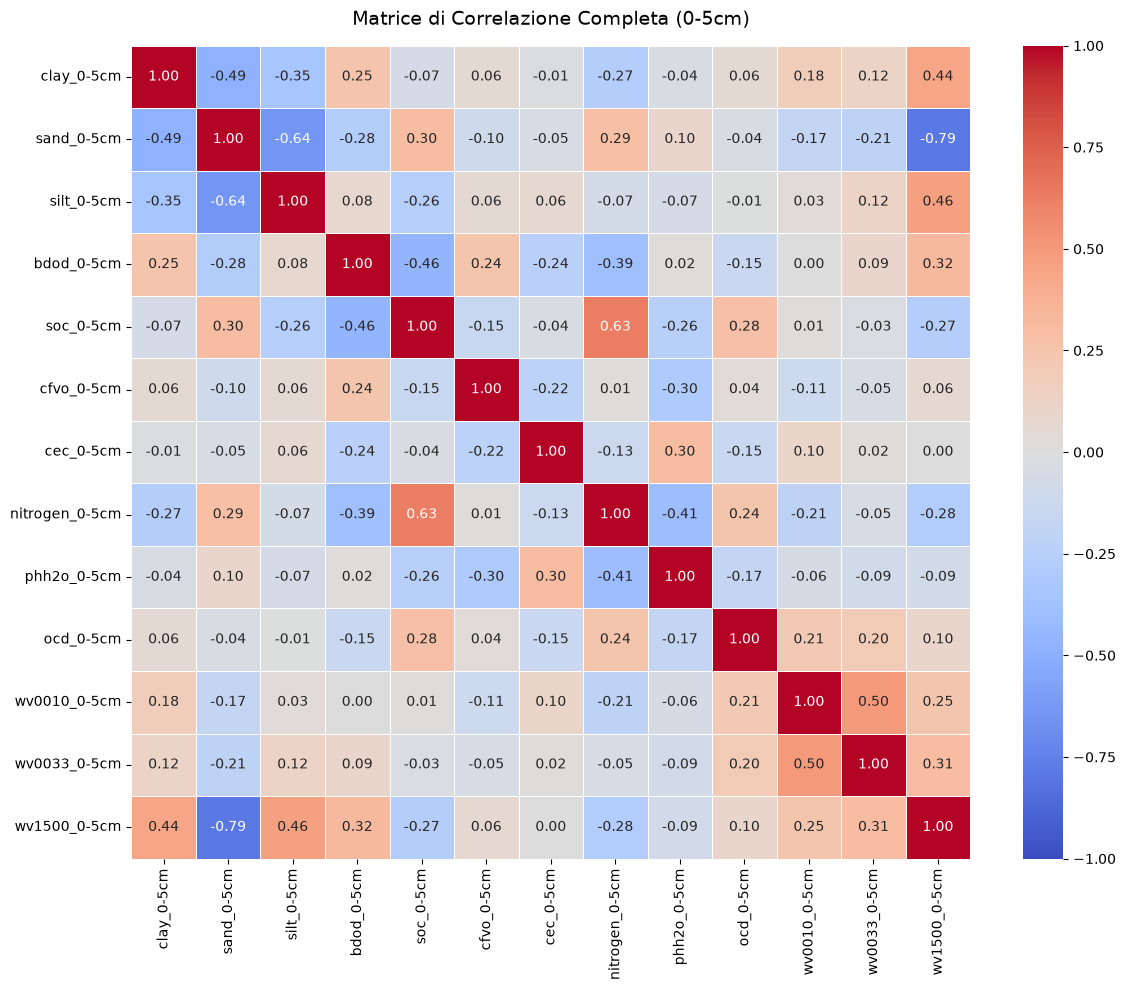

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("--- FASE 1: ESPLORAZIONE DATI (EDA) ---")

depth_level = '0-5cm'
vars_fisiche_3d = ['clay', 'sand', 'silt', 'bdod', 'soc', 'cfvo']
vars_chimiche_idr = ['cec', 'nitrogen', 'phh2o', 'ocd', 'wv0010', 'wv0033', 'wv1500']
all_vars = vars_fisiche_3d + vars_chimiche_idr

# 1. Estrazione coerente tramite slicing xarray
selected_layers = {}
for var in all_vars:
    if var in ds_scaled.data_vars:
        da = ds_scaled[var]
        if 'depth' in da.dims:
            selected_layers[f"{var}_{depth_level}"] = da.sel(depth=depth_level)
        else:
            selected_layers[f"{var}_{depth_level}"] = da
    elif f"{var}_depth_mean" in ds_scaled.data_vars:
        selected_layers[f"{var}_depth_mean"] = ds_scaled[f"{var}_depth_mean"]

# Conversione vettorializzata preservando l'allineamento spaziale
df_eda = pd.DataFrame({k: v.values.ravel() for k, v in selected_layers.items()})
df_eda.dropna(inplace=True)
df_eda.reset_index(drop=True, inplace=True)

print(f"Pixel totali estratti (senza NaN): {len(df_eda):,}")

# 2. Pulizia outlier e valori No-Data vettorializzata
valid_mask = pd.Series(True, index=df_eda.index)

for col in df_eda.columns:
    # ELIMINIAMO IL MARE E I NO-DATA: argilla, pH, ecc. non possono fisicamente essere = 0
    if any(t in col for t in ['phh2o', 'bdod', 'clay', 'sand', 'silt', 'soc']):
        valid_mask &= (df_eda[col] > 0)
    else:
        valid_mask &= (df_eda[col] >= 0)

# Limiti fisici specifici
for col in df_eda.columns:
    if 'phh2o' in col:
        valid_mask &= (df_eda[col] <= 14.0)
    elif any(t in col for t in ['clay', 'sand', 'silt', 'cfvo']):
        valid_mask &= (df_eda[col] <= 100.0)
    elif 'bdod' in col:
        valid_mask &= (df_eda[col] <= 2.8)
    else:
        q_high = df_eda[col].quantile(0.999)
        valid_mask &= (df_eda[col] <= q_high)

df_eda = df_eda[valid_mask].reset_index(drop=True)
print(f"Pixel validi dopo la pulizia: {len(df_eda):,}")

# 3. Controlli di consistenza idrologica e granulometrica
c_col, s_col, z_col = f"clay_{depth_level}", f"sand_{depth_level}", f"silt_{depth_level}"
if c_col in df_eda and s_col in df_eda and z_col in df_eda:
    text_sum = df_eda[c_col] + df_eda[s_col] + df_eda[z_col]
    print(f"Tessitura (Somma %): media = {text_sum.mean():.1f}% | range = [{text_sum.min():.1f}%, {text_sum.max():.1f}%]")

fc_col, wp_col = f"wv0033_{depth_level}", f"wv1500_{depth_level}"
if fc_col in df_eda and wp_col in df_eda:
    anomalie_awc = (df_eda[fc_col] <= df_eda[wp_col]).sum()
    print(f"Inversioni idrauliche (Capacità di Campo <= Punto di Appassimento): {anomalie_awc:,} pixel")

# 4. Campionamento per i plot
df_plot = df_eda.sample(n=min(len(df_eda), 50000), random_state=42)

# Define eda_cols for plotting
eda_cols = df_plot.columns.tolist()

# 5. Visualizzazione: Heatmap di correlazione (MATRICE INTERA)
plt.figure(figsize=(12, 10)) # Dimensioni leggermente aumentate per una migliore leggibilità
corr_matrix = df_plot[eda_cols].corr()

# Disegniamo la heatmap senza la maschera triangolare
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    vmin=-1,
    vmax=1,
    linewidths=0.5
)
plt.title(f"Matrice di Correlazione Completa ({depth_level})", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

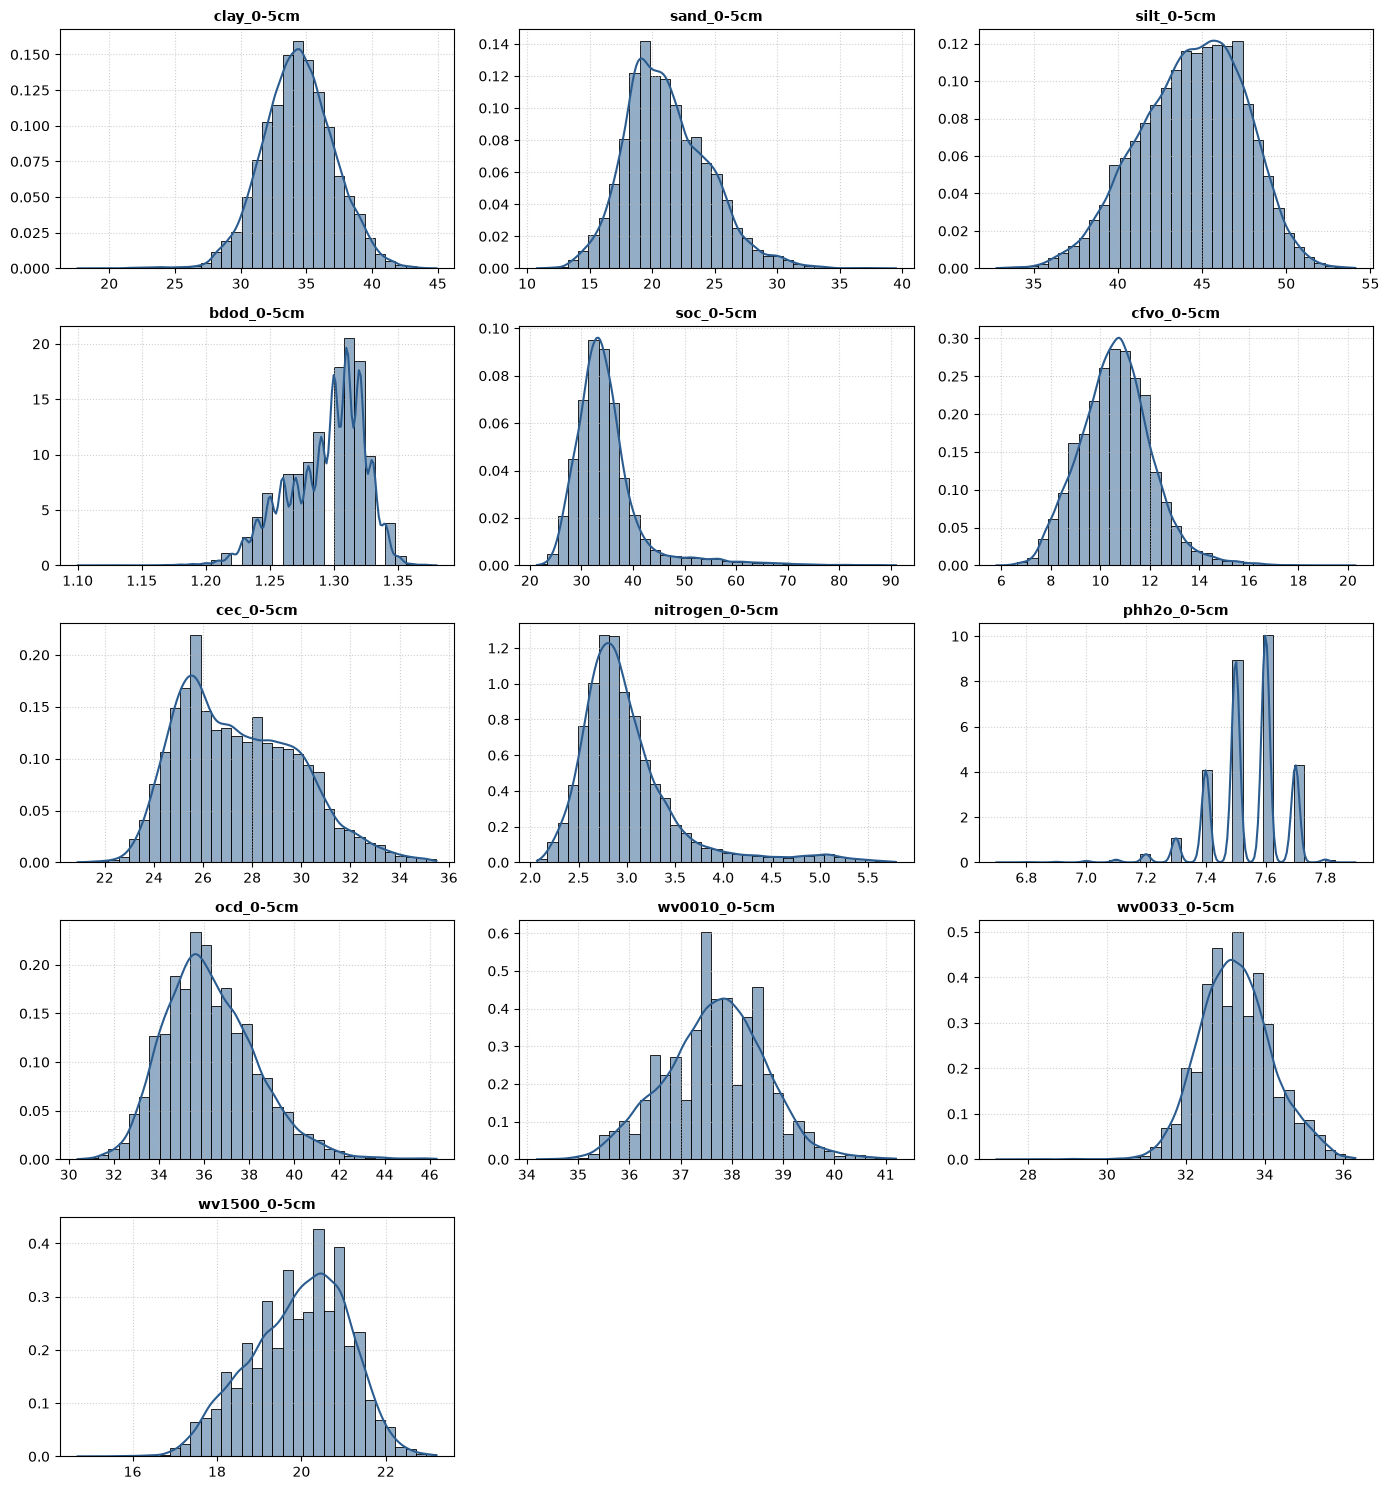

In [4]:
# 6. Distribuzioni delle variabili
ncols = 3
nrows = int(np.ceil(len(eda_cols) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 3 * nrows))
axes = np.atleast_1d(axes).ravel()

for i, col in enumerate(eda_cols):
    sns.histplot(df_plot[col], bins=35, kde=True, ax=axes[i], color='#2b5c8f', stat="density")
    axes[i].set_title(col, fontsize=10, weight='bold')
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")
    axes[i].grid(True, linestyle=':', alpha=0.6)

for j in range(len(eda_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

#**FASE 2: Feature Engineering (Dinamiche Verticali)**
### Per superare i limiti di un clustering bidimensionale, ingegnerizziamo nuove feature che descrivono come il suolo si trasforma scendendo in profondità.
###Calcoliamo:
###1. **Delta Totale:** Differenza netta fondo - superficie.
###2. **Gradienti Normalizzati:** Tasso di variazione tra strati consecutivi diviso per la distanza (in cm) tra i centri dei layer, per normalizzare spessori diversi.

In [5]:
import numpy as np
import xarray as xr

print("--- FASE 2: FEATURE ENGINEERING (15 Gradienti Fisico-Idraulici Normalizzati) ---")

layer_midpoints = {
    '0-5cm': 2.5,
    '5-15cm': 10.0,
    '15-30cm': 22.5,
    '30-60cm': 45.0,
    '60-100cm': 80.0,
    '100-200cm': 150.0
}

def calc_gradient(da, l_top, l_bottom):
    dz = layer_midpoints[l_bottom] - layer_midpoints[l_top]
    return (da.sel(depth=l_bottom) - da.sel(depth=l_top)) / dz

feature_specs = [
    # 1. Dinamica Tessiturale Argillosa (Orizzonti A e Bt)
    ('clay', '0-5cm', '5-15cm', 'clay_grad_0-5_to_5-15'),
    ('clay', '5-15cm', '15-30cm', 'clay_grad_5-15_to_15-30'),
    ('clay', '15-30cm', '30-60cm', 'clay_grad_15-30_to_30-60'),

    # 2. Dinamica Sabbia (Discontinuità sedimentarie)
    #('sand', '15-30cm', '30-60cm', 'sand_grad_15-30_to_30-60'),
    ('sand', '30-60cm', '60-100cm', 'sand_grad_30-60_to_60-100'),

    # 3. Scheletro / Frazione grossolana (Transizioni litologiche e alluvionali)
    ('cfvo', '15-30cm', '30-60cm', 'cfvo_grad_15-30_to_30-60'),
    ('cfvo', '60-100cm', '100-200cm', 'cfvo_grad_60-100_to_100-200'),

    # 4. Sostanza Organica (Topsoil)
    ('soc', '0-5cm', '5-15cm', 'soc_grad_0-5_to_5-15'),
    ('soc', '5-15cm', '15-30cm', 'soc_grad_5-15_to_15-30'),

    # 5. Compattazione / Struttura (Bulk Density)
    ('bdod', '5-15cm', '15-30cm', 'bdod_grad_5-15_to_15-30'),   # Suola di aratura
    ('bdod', '15-30cm', '30-60cm', 'bdod_grad_15-30_to_30-60'),
    ('bdod', '30-60cm', '60-100cm', 'bdod_grad_30-60_to_60-100'),

    # 6. Comportamento Idraulico / Drenaggio Verticale
    ('Ksat', '0-5cm', '5-15cm', 'Ksat_grad_0-5_to_5-15'),
    #('Ksat', '5-15cm', '15-30cm', 'Ksat_grad_5-15_to_15-30'),
    ('Ksat', '15-30cm', '30-60cm', 'Ksat_grad_15-30_to_30-60')
]

gradient_features = {}
for var, top, bot, name in feature_specs:
    gradient_features[name] = calc_gradient(ds_scaled[var], top, bot)

ds_gradients = xr.Dataset(gradient_features)
df_ml = ds_gradients.to_dataframe().dropna().reset_index()

selected_ml_cols = list(gradient_features.keys())
X_raw = df_ml[selected_ml_cols].values

print(f"Feature generate con successo: {len(selected_ml_cols)}")

--- FASE 2: FEATURE ENGINEERING (15 Gradienti Fisico-Idraulici Normalizzati) ---
Feature generate con successo: 13


#**Analisi di Correlazione sulle Nuove Feature**
### Verifichiamo la validità agronomica dei gradienti creati. Ci aspettiamo, ad esempio, una forte correlazione negativa tra la dinamica dell'argilla e quella della sabbia (all'aumentare dell'una lungo il profilo, l'altra cala).

--- ANALISI CORRELAZIONE COMPLETA DEI GRADIENTI VERTICALI (13 FEATURE) ---


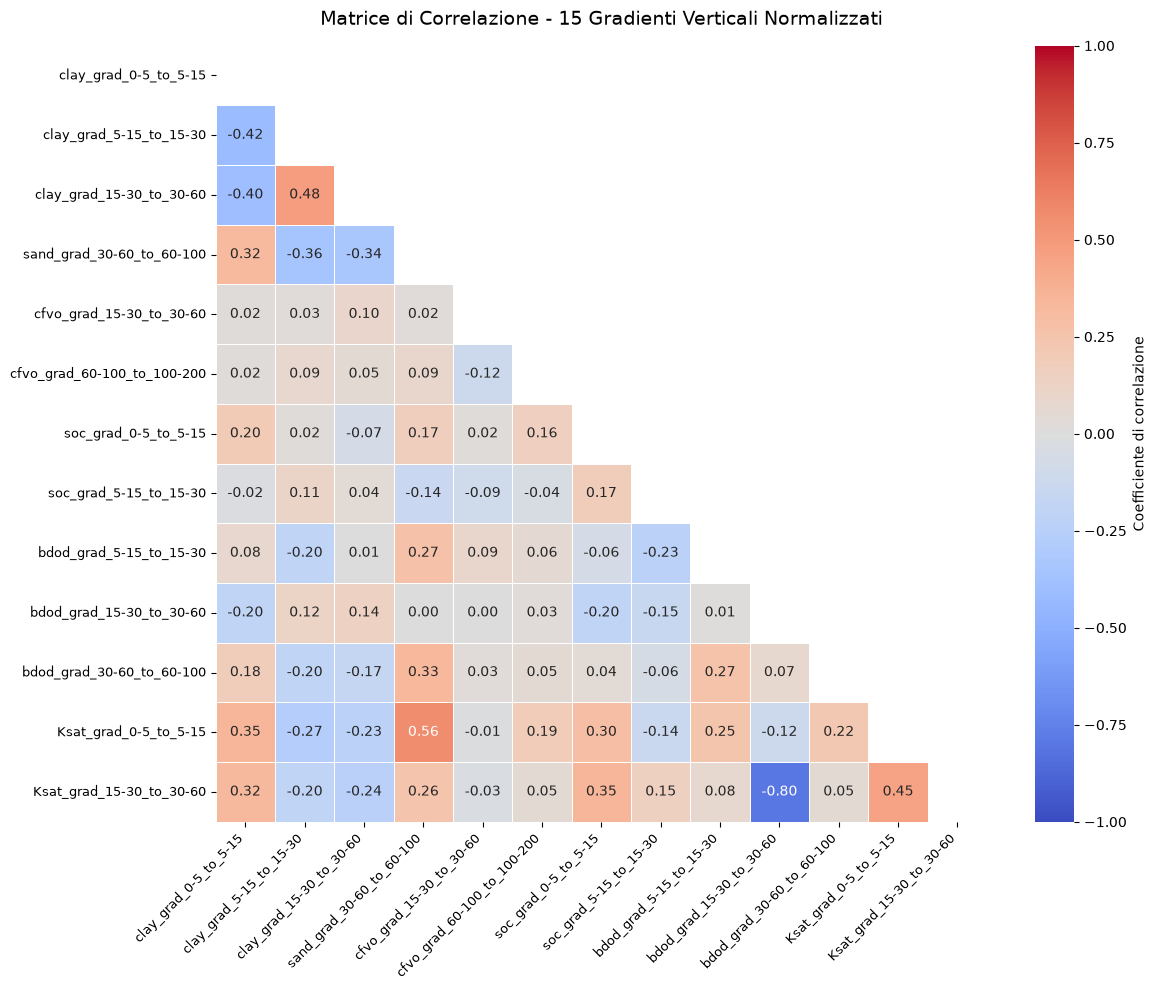


Nessuna coppia supera la soglia critica |r| > 0.8: lo spazio delle feature è ben bilanciato.


In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("--- ANALISI CORRELAZIONE COMPLETA DEI GRADIENTI VERTICALI (13 FEATURE) ---")

# Calcolo matrice di correlazione di Pearson (o Spearman se ci sono code lunghe)
corr_matrix = df_ml[selected_ml_cols].corr(method='pearson')

# Maschera per nascondere il triangolo superiore ridondante
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    cbar_kws={'label': 'Coefficiente di correlazione'}
)
plt.title('Matrice di Correlazione - 15 Gradienti Verticali Normalizzati', fontsize=14, pad=15)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

# Check automatico di coppie critiche (|r| > 0.8)
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        val = corr_matrix.iloc[i, j]
        if abs(val) > 0.8:
            high_corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], val))

if high_corr_pairs:
    print("\nAttenzione: rilevate coppie con forte collinearità (|r| > 0.8):")
    for f1, f2, r in high_corr_pairs:
        print(f"- {f1} <--> {f2}: r = {r:.2f}")
else:
    print("\nNessuna coppia supera la soglia critica |r| > 0.8: lo spazio delle feature è ben bilanciato.")

#**FASE 3: Preparazione Dati e Ricerca Iperparametri**
### Le 15 nuove feature hanno scale e deviazioni standard diverse; applichiamo uno `StandardScaler` per evitare distorsioni nel calcolo delle distanze euclidee.
### Successivamente, ricerchiamo il $K$ ottimale per il K-Means tramite Metodo del Gomito, Silhouette Score, CH e DB su un campione di pixel.

--- PREPARAZIONE DEL DATASET E STANDARDIZZAZIONE ---
Shape X_raw: (89786, 13)
Shape X_scaled: (89786, 13)
--> Dataset campionato a 15000 osservazioni per l'analisi dei K.

Calcolo metriche (Inerzia, Silhouette, Davies-Bouldin, Calinski-Harabasz)...



--- RIEPILOGO K SUGGERITI ---
               Metodo / Metrica        Criterio  K suggerito
Metodo del Gomito (KneeLocator) Punto di flesso            6
         Silhouette Score (Max)         Massimo            2
           Davies-Bouldin (Min)          Minimo           11
        Calinski-Harabasz (Max)         Massimo            2

>>> K FINALE SCELTO PER IL MODELLO: 6 <<<


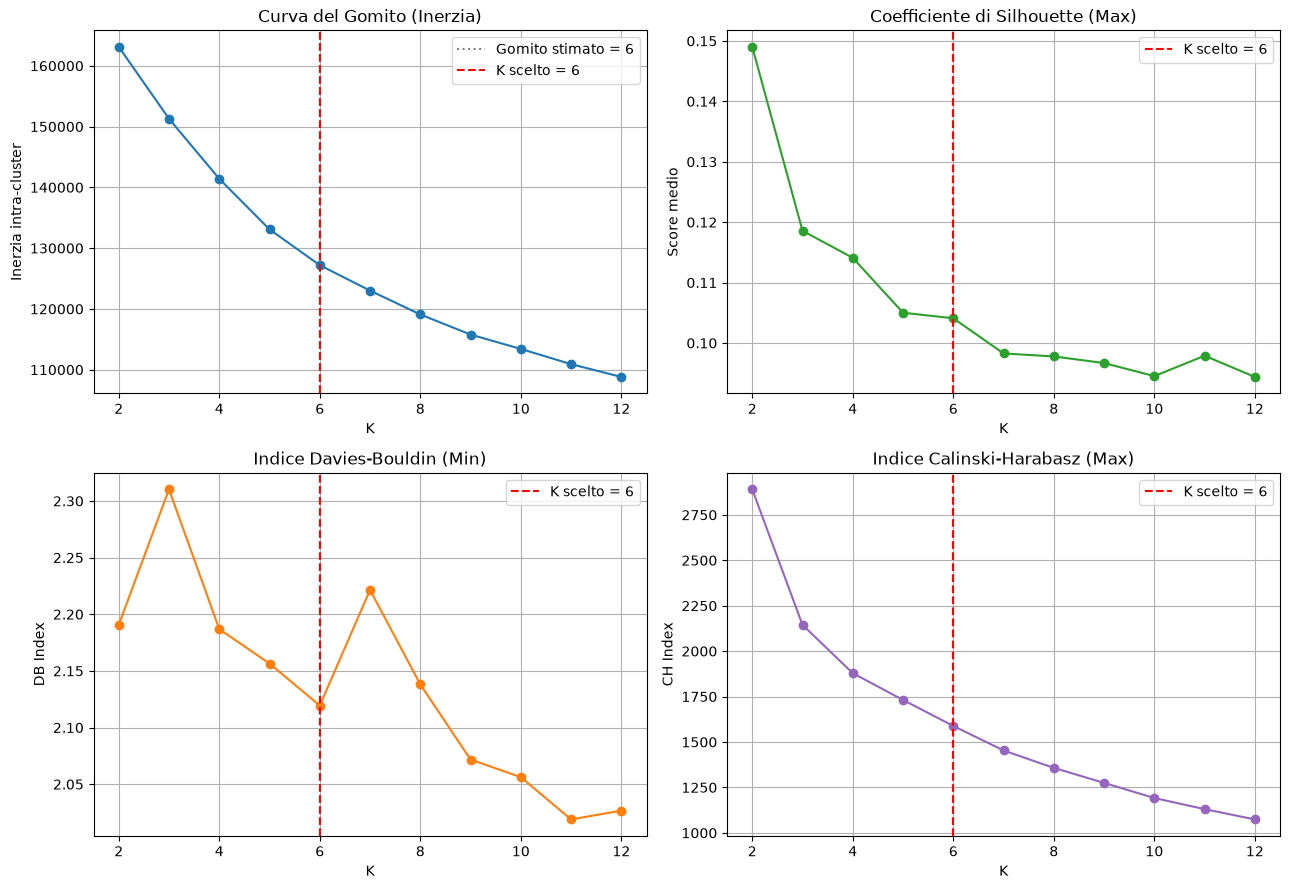


Addestramento del modello finale (K=6) su 89786 osservazioni...


Inerzia finale: 762167.37

Distribuzione finale dei cluster:
cluster
0    17652
1    15976
2     4317
3    18413
4    18914
5    14514


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)
from scipy.optimize import linear_sum_assignment
from sklearn.metrics import confusion_matrix
from matplotlib.colors import ListedColormap

#per allineamento colori
def align_clusters(y_ref, y_target):
    cm = confusion_matrix(y_ref, y_target)
    row_ind, col_ind = linear_sum_assignment(-cm)
    mapping = {target_col: ref_row for ref_row, target_col in zip(row_ind, col_ind)}
    return np.array([mapping[val] for val in y_target])

# Gestione installazione automatica di kneed
try:
    from kneed import KneeLocator
except ImportError:
    import sys, subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "kneed"])
    from kneed import KneeLocator

print("--- PREPARAZIONE DEL DATASET E STANDARDIZZAZIONE ---")

# 1. Selezione feature e standardizzazione
X_raw = df_ml[selected_ml_cols].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

print(f"Shape X_raw: {X_raw.shape}")
print(f"Shape X_scaled: {X_scaled.shape}")

# 2. Campionamento per velocizzare il calcolo delle metriche O(N^2)
MAX_SAMPLES = 15000
if X_scaled.shape[0] > MAX_SAMPLES:
    np.random.seed(42)
    idx = np.random.choice(X_scaled.shape[0], MAX_SAMPLES, replace=False)
    X_search = X_scaled[idx]
    print(f"--> Dataset campionato a {MAX_SAMPLES} osservazioni per l'analisi dei K.")
else:
    X_search = X_scaled

# --- CALCOLO METRICHE INTERNE AL VARIARE DI K ---
k_values = list(range(2, 13))
inertia_values = []
silhouette_scores = []
db_scores = []
ch_scores = []

print("\nCalcolo metriche (Inerzia, Silhouette, Davies-Bouldin, Calinski-Harabasz)...")
for k in k_values:
    # k-means++ garantisce convergenza veloce e stabile senza variare init/max_iter
    model = KMeans(n_clusters=k, init="k-means++", n_init=10, max_iter=300, random_state=42)
    labels = model.fit_predict(X_search)

    inertia_values.append(model.inertia_)
    silhouette_scores.append(silhouette_score(X_search, labels))
    db_scores.append(davies_bouldin_score(X_search, labels))       # Minimo = Migliore
    ch_scores.append(calinski_harabasz_score(X_search, labels))   # Massimo = Migliore

# --- INDIVIDUAZIONE AUTOMATICA DEI MIGLIORI K ---
# Calcolo geometrico robusto del punto di gomito
kneedle = KneeLocator(
    k_values,
    inertia_values,
    curve="convex",
    direction="decreasing",
    interp_method="polynomial"
)
best_k_elbow = kneedle.elbow

best_k_silhouette = k_values[int(np.argmax(silhouette_scores))]
best_k_dbi = k_values[int(np.argmin(db_scores))]
best_k_ch = k_values[int(np.argmax(ch_scores))]

# Tabella di riepilogo
k_summary = pd.DataFrame({
    "Metodo / Metrica": [
        "Metodo del Gomito (KneeLocator)",
        "Silhouette Score (Max)",
        "Davies-Bouldin (Min)",
        "Calinski-Harabasz (Max)"
    ],
    "Criterio": ["Punto di flesso", "Massimo", "Minimo", "Massimo"],
    "K suggerito": [best_k_elbow, best_k_silhouette, best_k_dbi, best_k_ch]
})

print("\n--- RIEPILOGO K SUGGERITI ---")
print(k_summary.to_string(index=False))

# --- SCELTA FINALE DI K ---
# K=5 scelto unendo l'analisi tecnica al vincolo agronomico di dominio
k_final = 6
print(f"\n>>> K FINALE SCELTO PER IL MODELLO: {k_final} <<<")

# --- PLOT DELLE 4 METRICHE ---
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# 1. Gomito
axes[0, 0].plot(k_values, inertia_values, marker="o", color="#1f77b4")
if best_k_elbow is not None:
    axes[0, 0].axvline(x=best_k_elbow, color="gray", linestyle=":", label=f"Gomito stimato = {best_k_elbow}")
axes[0, 0].axvline(x=k_final, color="red", linestyle="--", label=f"K scelto = {k_final}")
axes[0, 0].set_title("Curva del Gomito (Inerzia)")
axes[0, 0].set_xlabel("K")
axes[0, 0].set_ylabel("Inerzia intra-cluster")
axes[0, 0].legend()
axes[0, 0].grid(True)

# 2. Silhouette
axes[0, 1].plot(k_values, silhouette_scores, marker="o", color="#2ca02c")
axes[0, 1].axvline(x=k_final, color="red", linestyle="--", label=f"K scelto = {k_final}")
axes[0, 1].set_title("Coefficiente di Silhouette (Max)")
axes[0, 1].set_xlabel("K")
axes[0, 1].set_ylabel("Score medio")
axes[0, 1].legend()
axes[0, 1].grid(True)

# 3. Davies-Bouldin
axes[1, 0].plot(k_values, db_scores, marker="o", color="#ff7f0e")
axes[1, 0].axvline(x=k_final, color="red", linestyle="--", label=f"K scelto = {k_final}")
axes[1, 0].set_title("Indice Davies-Bouldin (Min)")
axes[1, 0].set_xlabel("K")
axes[1, 0].set_ylabel("DB Index")
axes[1, 0].legend()
axes[1, 0].grid(True)

# 4. Calinski-Harabasz
axes[1, 1].plot(k_values, ch_scores, marker="o", color="#9467bd")
axes[1, 1].axvline(x=k_final, color="red", linestyle="--", label=f"K scelto = {k_final}")
axes[1, 1].set_title("Indice Calinski-Harabasz (Max)")
axes[1, 1].set_xlabel("K")
axes[1, 1].set_ylabel("CH Index")
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

# --- ADDESTRAMENTO FINALE SULL'INTERO DATASET ---
print(f"\nAddestramento del modello finale (K={k_final}) su {X_scaled.shape[0]} osservazioni...")
final_model = KMeans(
    n_clusters=k_final,
    init="k-means++",
    n_init=20,          # Più run per convergenza ottimale sui dati completi
    max_iter=300,
    random_state=42
)

df_ml["cluster"] = final_model.fit_predict(X_scaled)

print(f"Inerzia finale: {final_model.inertia_:.2f}")
print("\nDistribuzione finale dei cluster:")
print(df_ml["cluster"].value_counts().sort_index().to_string())



#**Visualizzazione Avanzata delle Metriche (Yellowbrick)**
###Per validare visivamente la scelta del K ottimale e la qualità della
###separazione dei cluster, integriamo i visualizer della libreria Yellowbrick.
### 1. **KElbowVisualizer**: Mostra il punto di flesso (Gomito) in modo automatico.
### 2. **SilhouetteVisualizer**: Mostra la densità e lo sbilanciamento dei cluster per K=5.
### 3. **InterclusterDistance**: Proietta i centri dei cluster in 2D per valutarne la sovrapposizione.

--- ANALISI VISIVA AVANZATA (YELLOWBRICK) ---

1. Generazione del grafico K-Elbow...


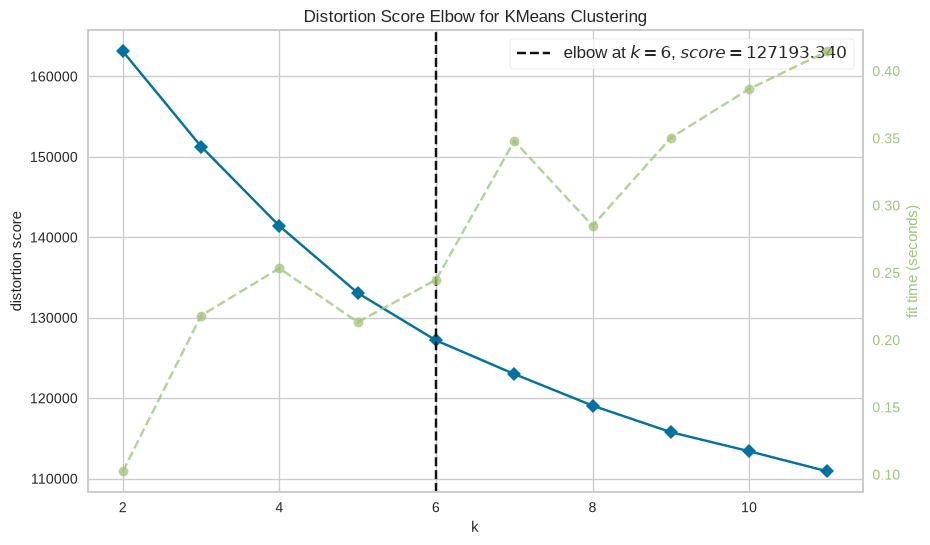

In [8]:
from sklearn.cluster import KMeans
from yellowbrick.cluster.elbow import kelbow_visualizer
from yellowbrick.cluster import silhouette_visualizer
from yellowbrick.cluster import intercluster_distance
import matplotlib.pyplot as plt

print("--- ANALISI VISIVA AVANZATA (YELLOWBRICK) ---")

# 1. GRAFICO DEL GOMITO (ELBOW METHOD)
print("\n1. Generazione del grafico K-Elbow...")
plt.figure(figsize=(10, 6))
# kelbow_visualizer fa fit e plot in un solo colpo
kelbow_visualizer(KMeans(random_state=42, init='k-means++', n_init=10), X_search, k=(2, 12))
plt.show()


2. Generazione del profilo Silhouette per K=6...


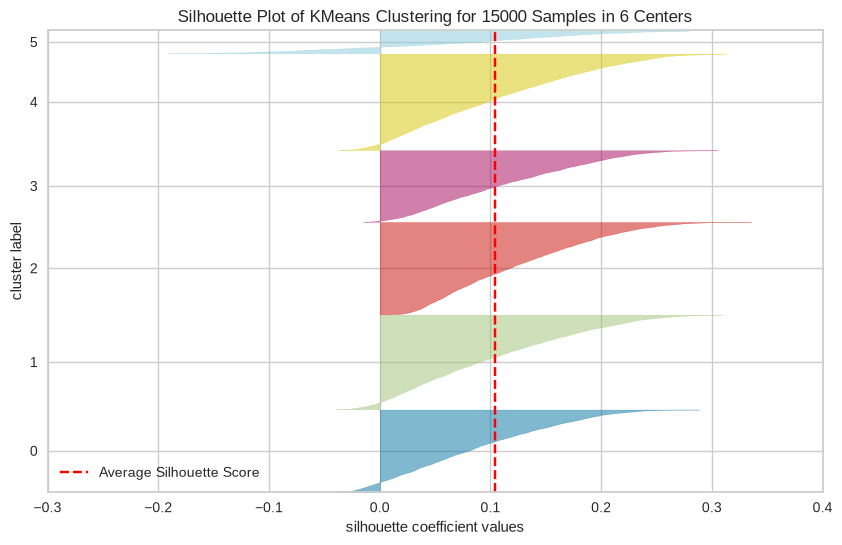

<Figure size 800x550 with 0 Axes>

In [9]:
# 2. GRAFICO DELLA SILHOUETTE (Per K=6)
print("\n2. Generazione del profilo Silhouette per K=6...")
plt.figure(figsize=(10, 6))
# silhouette_visualizer calcola il coefficiente per ogni campione e lo colora
silhouette_visualizer(KMeans(n_clusters=6, random_state=42, init='k-means++', n_init=10), X_search, colors='yellowbrick')
plt.show()


3. Generazione della Mappa delle Distanze Inter-Cluster per K=6...


/home/mattiamassolari/.local/lib/python3.14/site-packages/sklearn/manifold/_mds.py:735: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(


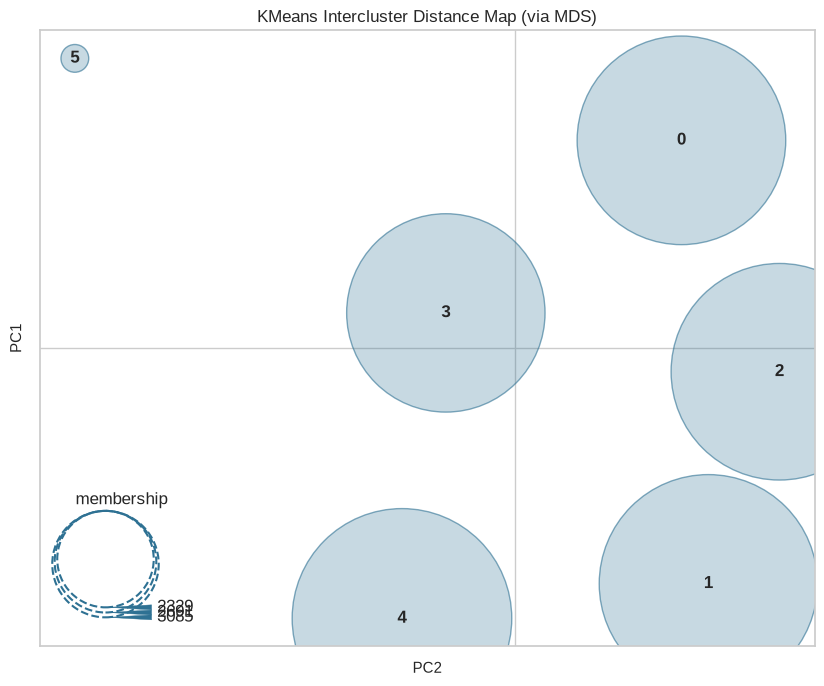

<Figure size 800x550 with 0 Axes>

In [10]:
# 3. MAPPA DELLE DISTANZE INTER-CLUSTER (Per K=6)
print("\n3. Generazione della Mappa delle Distanze Inter-Cluster per K=6...")
plt.figure(figsize=(10, 8))
# intercluster_distance mappa i centroidi in 2D e ne mostra le dimensioni
intercluster_distance(KMeans(n_clusters=6, random_state=42, init='k-means++', n_init=10), X_search)
plt.show()

#**Visualizzazione dei Cluster nello Spazio delle Feature (PCA)**
### Avendo a disposizione 13 feature (alta dimensionalità), non è possibile visualizzare direttamente i pixel in un grafico. Utilizziamo la Principal Component Analysis (PCA) per comprimere il dataset in 2 dimensioni principali.Questo scatter plot ci permette di verificare visivamente se i cluster pedologici individuati dal K-Means sono ben separati nello spazio chimico-fisico.

--- ANALISI DELLE COMPONENTI PRINCIPALI (PCA) ---


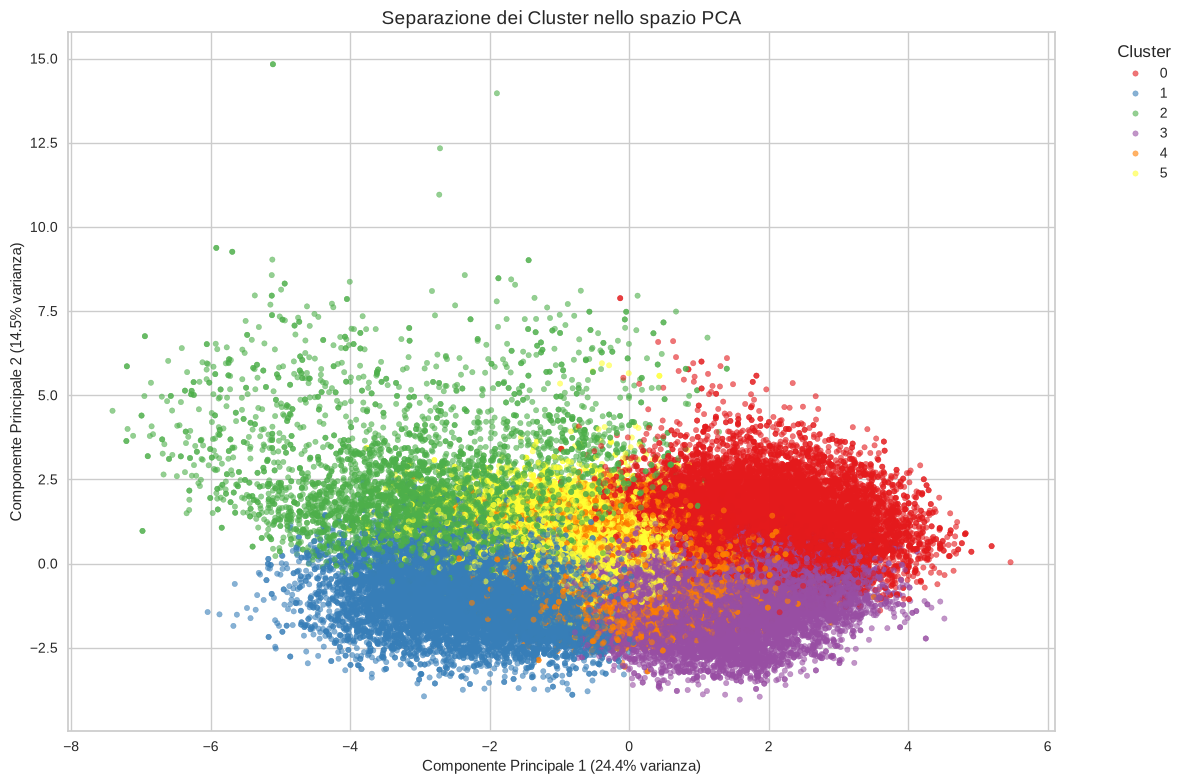

In [11]:
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt

print("--- ANALISI DELLE COMPONENTI PRINCIPALI (PCA) ---")

# Inizializziamo e applichiamo la PCA per ridurre a 2 dimensioni
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

final_labels = final_model.fit_predict(X_scaled)
df_ml['cluster'] = final_labels

# Creiamo un DataFrame temporaneo per il plotting
df_pca = pd.DataFrame(data=X_pca, columns=['Componente Principale 1', 'Componente Principale 2'])
df_pca['Cluster'] = final_labels

# Calcoliamo la varianza spiegata
varianza_spiegata = pca.explained_variance_ratio_ * 100

plt.figure(figsize=(12, 8))

# Generiamo lo scatter plot colorando i punti in base al cluster
sns.scatterplot(
    x='Componente Principale 1',
    y='Componente Principale 2',
    hue='Cluster',
    palette='Set1', # Usiamo la stessa palette della mappa geografica
    data=df_pca,
    s=15,
    alpha=0.6,
    edgecolor=None
)

plt.title("Separazione dei Cluster nello spazio PCA", fontsize=14)
plt.xlabel(f"Componente Principale 1 ({varianza_spiegata[0]:.1f}% varianza)")
plt.ylabel(f"Componente Principale 2 ({varianza_spiegata[1]:.1f}% varianza)")
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

#**FASE 4: Mappatura Spaziale dei Cluster**
### Ricostruiamo la griglia spaziale a partire dal DataFrame Pandas e la proiettiamo su mappa 2D. Anche se l'algoritmo non ha ricevuto coordinate, ci aspettiamo che cluster pedologici assumano una distribuzione spaziale coerente sul territorio analizzato.

--- FASE 4: MAPPATURA SPAZIALE DEI CLUSTER ---


Inerzia finale: 762167.3657

Distribuzione dei cluster finali sui pixel totali:
cluster
0    17652
1    15976
2     4317
3    18413
4    18914
5    14514


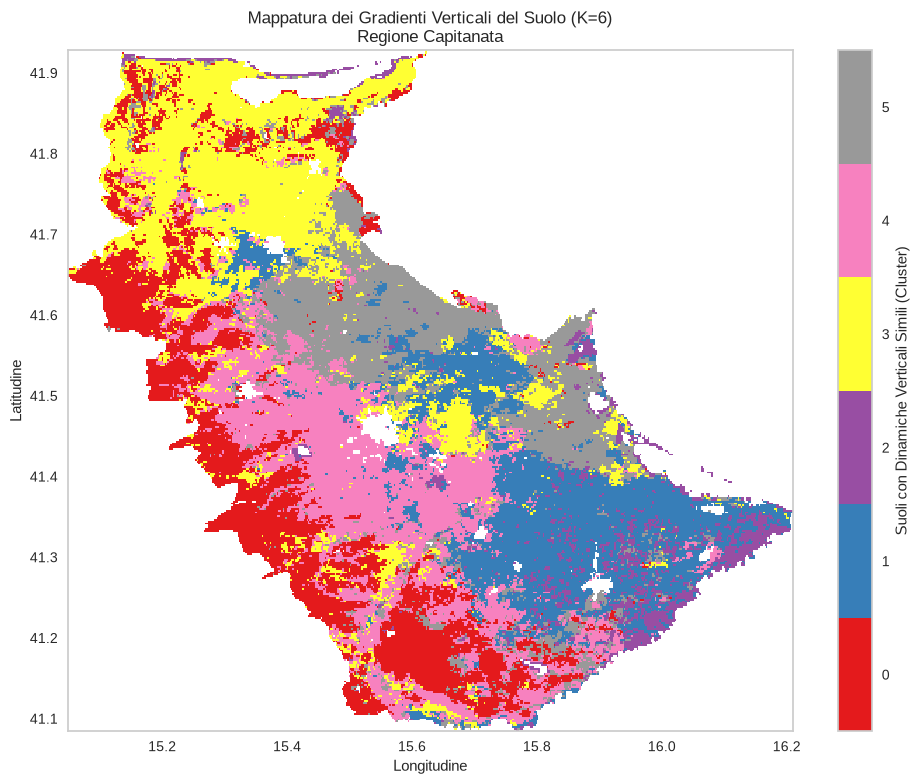

In [12]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

print("--- FASE 4: MAPPATURA SPAZIALE DEI CLUSTER ---")

soil_cmap = ListedColormap(['#e41a1c', '#377eb8', '#984ea3', '#ffff33', '#f781bf', '#999999'])

# 1. Ricostruzione della griglia spaziale
# Impostiamo lat e lon come indici e convertiamo la colonna 'cluster' in una struttura xarray DataArray
da_clusters = df_ml.set_index(['lat', 'lon'])['cluster'].to_xarray()

# 2. Configurazione del Plot
plt.figure(figsize=(10, 8))

# Creiamo una colormap discreta adatta ai cluster (categorie e non valori continui)
# Usiamo k_final che è stato dinamicamente scelto dalla tua pipeline
cmap = plt.get_cmap('Set1', k_final)

# Riadestriamo il modello finale con K=6
final_model = KMeans(
    n_clusters=k_final,
    init='k-means++',
    n_init=20,
    max_iter=300,
    random_state=42
)

# Fit the model and get the labels
final_labels = final_model.fit_predict(X_scaled)
# Update the 'cluster' column in df_ml with the new labels
df_ml['cluster'] = final_labels

print(f'Inerzia finale: {final_model.inertia_:.4f}')
print('\nDistribuzione dei cluster finali sui pixel totali:')
print(df_ml['cluster'].value_counts().sort_index().to_string())

# 3. Creazione della mappa
ax = plt.axes()
da_clusters.plot(ax=ax, cmap=soil_cmap, add_colorbar=False)

# Aggiungiamo una colorbar personalizzata che mostri i numeri esatti dei cluster
cbar = plt.colorbar(plt.cm.ScalarMappable(cmap=soil_cmap, norm=mcolors.Normalize(vmin=-0.5, vmax=k_final-0.5)),
                    ticks=range(k_final),
                    ax=ax)
cbar.set_label('Suoli con Dinamiche Verticali Simili (Cluster)')

plt.title(f"Mappatura dei Gradienti Verticali del Suolo (K={k_final})\nRegione Capitanata")
plt.xlabel("Longitudine")
plt.ylabel("Latitudine")

plt.tight_layout()
plt.show()

#**FASE 5: Profilazione Cluster**
### Una volta divisi i gruppi spazialmente, analizziamo i loro "Centroidi" standardizzati tramite Z-Score per capire *cosa* rende unico ogni cluster.Valori molto rossi indicano un gradiente (tasso di variazione) nettamente superiore alla media regionale, valori blu nettamente inferiore.

--- FASE 5: INTERPRETAZIONE DEI CLUSTER (PROFILAZIONE) ---


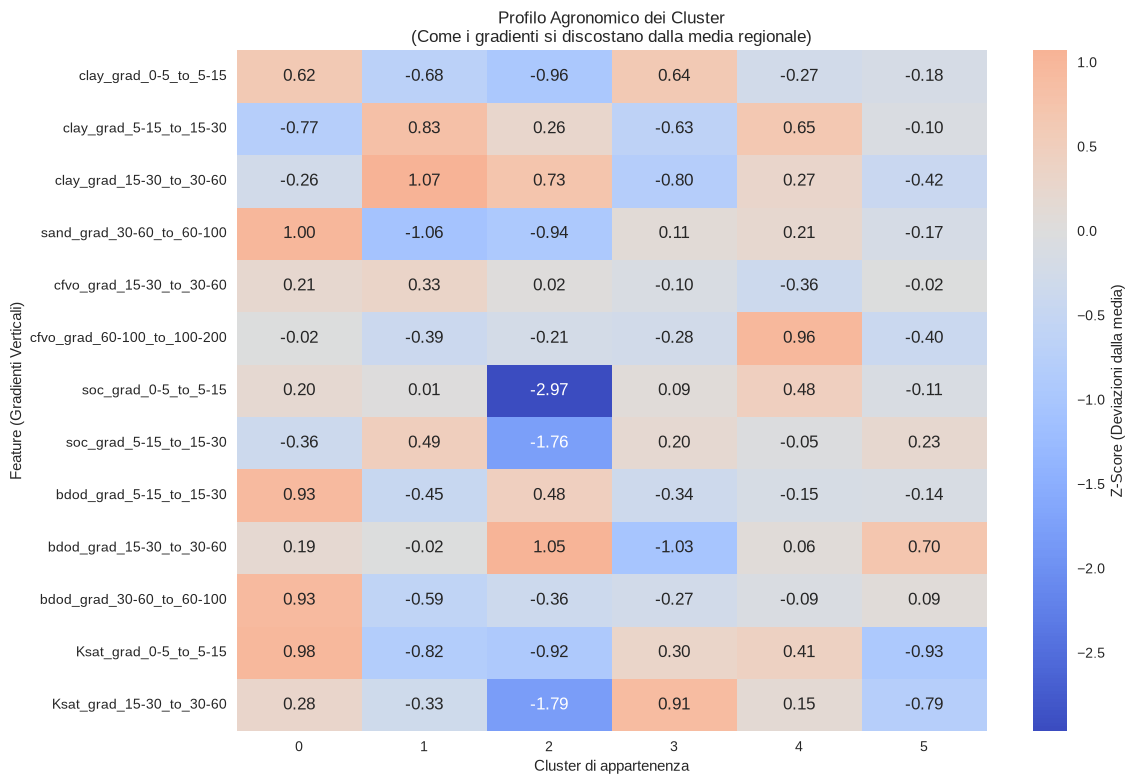

In [13]:
print("--- FASE 5: INTERPRETAZIONE DEI CLUSTER (PROFILAZIONE) ---")

# Creiamo un DataFrame con i centri dei cluster (i valori medi standardizzati calcolati dal K-Means)
centroids_df = pd.DataFrame(
    final_model.cluster_centers_,
    columns=selected_ml_cols
)
centroids_df.index.name = 'Cluster'

# Plottiamo la Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(centroids_df.T, cmap='coolwarm', annot=True, fmt=".2f", center=0, cbar_kws={'label': 'Z-Score (Deviazioni dalla media)'})

plt.title("Profilo Agronomico dei Cluster\n(Come i gradienti si discostano dalla media regionale)")
plt.xlabel("Cluster di appartenenza")
plt.ylabel("Feature (Gradienti Verticali)")

plt.tight_layout()
plt.show()

#**FASE 3b/4b: Apprendimento Basato sulla Densità (DBSCAN)**
### Per testare l'algoritmo DBSCAN cerchiamo prima l'Epsilon ottimale studiando la distanza K-NN. Il parametro `min_samples` viene settato a 26 per gestire le 13 variabili. Poiché operiamo in uno spazio di feature ad altissima dimensionalità, ci aspettiamo un forte impatto, con molti pixel sparsi visti come rumore o anomalia (-1).

--- FASE 3b: RICERCA PARAMETRI DBSCAN ---
Calcolo delle distanze K-NN per determinare l'Epsilon...


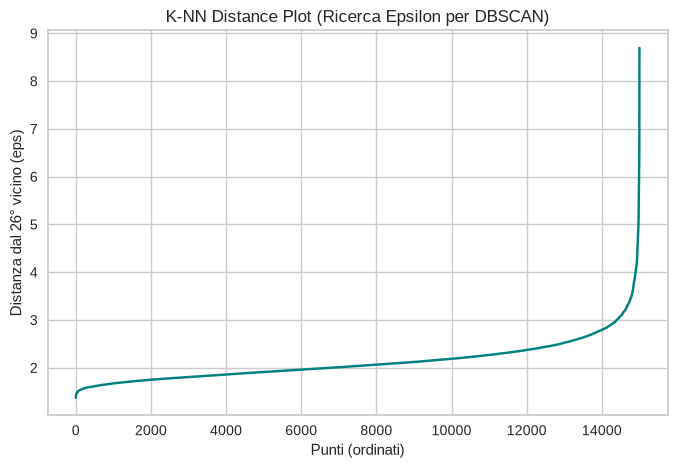

In [14]:
from sklearn.cluster import HDBSCAN
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import numpy as np

print("--- FASE 3b: RICERCA PARAMETRI DBSCAN ---")

MIN_SAMPLES = 26

print("Calcolo delle distanze K-NN per determinare l'Epsilon...")
nn = NearestNeighbors(n_neighbors=MIN_SAMPLES)
neighbors_fit = nn.fit(X_search)
distances, indices = neighbors_fit.kneighbors(X_search)

# Ordiniamo le distanze dal minore al maggiore
distances = np.sort(distances[:, MIN_SAMPLES-1], axis=0)

plt.figure(figsize=(8, 5))
plt.plot(distances, color='teal')
plt.title(f'K-NN Distance Plot (Ricerca Epsilon per DBSCAN)')
plt.xlabel('Punti (ordinati)')
plt.ylabel(f'Distanza dal {MIN_SAMPLES}° vicino (eps)')
plt.grid(True)
plt.show()



In [15]:
from sklearn.cluster import DBSCAN
import pandas as pd
import numpy as np

print("--- ESECUZIONE CLUSTERING BASATO SU DENSITÀ ---")

# OPZIONE 1: DBSCAN Standard
# Nota: un eps = 2.6 collassa in monocluster. Per spezzare la densità
# e catturare i nuclei più compatti serve un valore più stringente (es. 2.1 - 2.3).
EPS_SCELTO = 1.9

print(f"Addestramento DBSCAN (eps={EPS_SCELTO}, min_samples={MIN_SAMPLES})...")
dbscan_model = DBSCAN(eps=EPS_SCELTO, min_samples=MIN_SAMPLES, n_jobs=-1)

# Fit e predizione sull'intero dataset scalato
dbscan_labels = dbscan_model.fit_predict(X_scaled)

# Assegnazione dei cluster al DataFrame
df_ml['cluster_dbscan'] = dbscan_labels

# Statistiche e diagnostica dei cluster trovati
n_clusters_trovati = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = np.sum(dbscan_labels == -1)
noise_ratio = (n_noise / len(dbscan_labels)) * 100

print(f"\nNumero di cluster individuati (escluso rumore): {n_clusters_trovati}")
print(f"Pixel classificati come rumore/anomalia (-1): {n_noise} ({noise_ratio:.2f}%)")
print("\nDistribuzione dei campioni per cluster:")
print(pd.Series(dbscan_labels).value_counts().sort_index())

--- ESECUZIONE CLUSTERING BASATO SU DENSITÀ ---
Addestramento DBSCAN (eps=1.9, min_samples=26)...



Numero di cluster individuati (escluso rumore): 3
Pixel classificati come rumore/anomalia (-1): 5570 (6.20%)

Distribuzione dei campioni per cluster:
-1     5570
 0    84171
 1       16
 2       29
Name: count, dtype: int64


--- FASE 4b: MAPPATURA SPAZIALE DEI CLUSTER DBSCAN ---


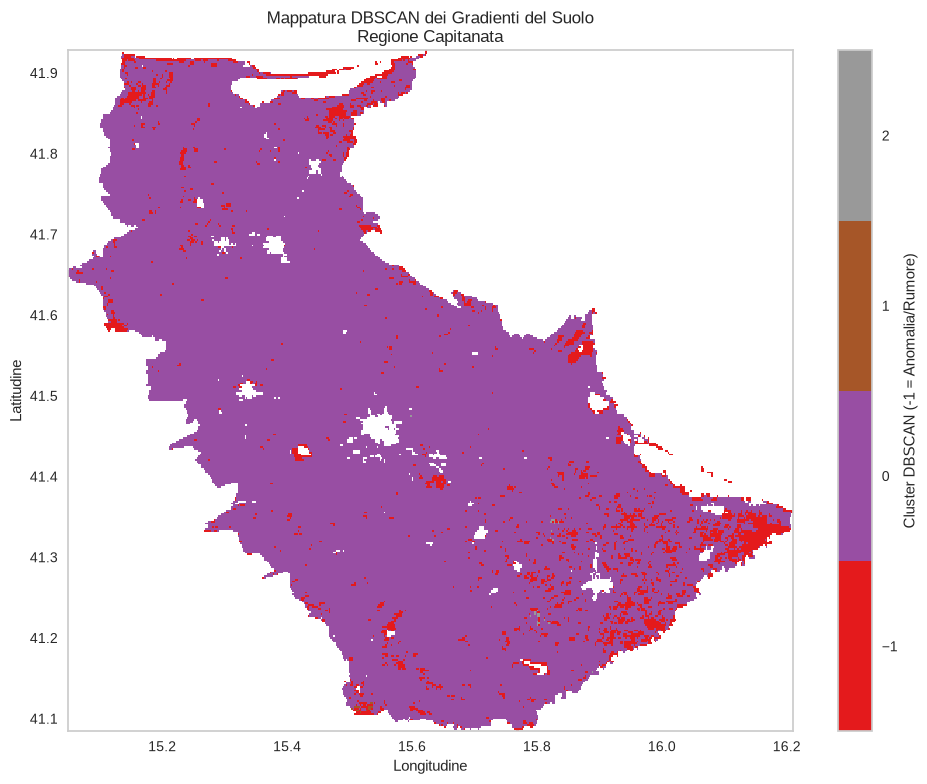

In [16]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

print("--- FASE 4b: MAPPATURA SPAZIALE DEI CLUSTER DBSCAN ---")

# Troviamo quanti cluster unici ha generato effettivamente il DBSCAN
valori_unici_dbscan = np.sort(df_ml['cluster_dbscan'].unique())
n_colori_dbscan = len(valori_unici_dbscan)
min_val = valori_unici_dbscan.min()
max_val = valori_unici_dbscan.max()

# Ricostruzione della griglia spaziale per DBSCAN
da_dbscan = df_ml.set_index(['lat', 'lon'])['cluster_dbscan'].to_xarray()

plt.figure(figsize=(10, 8))

# Creiamo una colormap dinamica
cmap = plt.get_cmap('Set1', n_colori_dbscan)

ax = plt.axes()
# da_dbscan.plot(ax=ax, cmap=cmap, add_colorbar=False)
da_dbscan.plot(ax=ax, cmap=cmap, vmin=min_val - 0.5, vmax=max_val + 0.5, add_colorbar=False)

# Colorbar personalizzata e dinamica
cbar = plt.colorbar(plt.cm.ScalarMappable(cmap=cmap, norm=mcolors.Normalize(vmin=min_val - 0.5, vmax=max_val + 0.5)),
                    ticks=valori_unici_dbscan,
                    ax=ax)
cbar.set_label('Cluster DBSCAN (-1 = Anomalia/Rumore)')

plt.title("Mappatura DBSCAN dei Gradienti del Suolo\nRegione Capitanata")
plt.xlabel("Longitudine")
plt.ylabel("Latitudine")

plt.tight_layout()
plt.show()

#**FASE 3c/4c: Clustering Gerarchico (Bisecting K-Means)**
### Valutiamo un approccio di partizionamento alternativo. A differenza del K-Means puro, il Bisecting K-Means suddivide un macro-cluster globale in un approccio iterativo *top-down*. Fissiamo $K=6$ per rendere il paragone finale il più equo possibile.

--- FASE 3c: ADDESTRAMENTO E MAPPATURA BISECTING K-MEANS ---

Distribuzione dei cluster Bisecting K-Means (allineati):
cluster_bisecting
0    22219
1    21410
2     4972
3    12126
4    13256
5    15803


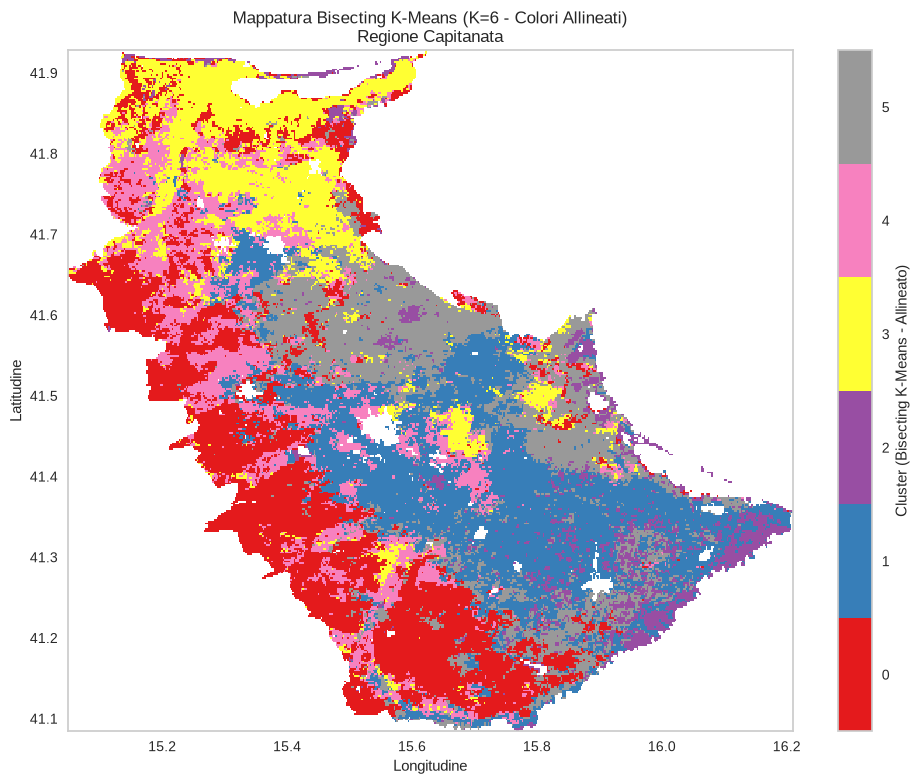

In [17]:
from sklearn.cluster import BisectingKMeans
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

print("--- FASE 3c: ADDESTRAMENTO E MAPPATURA BISECTING K-MEANS ---")

K_BISECTING = 6
bisect_kmeans = BisectingKMeans(n_clusters=K_BISECTING, random_state=42)

# Fit e predizione con allineamento immediato delle etichette
bisect_labels = bisect_kmeans.fit_predict(X_scaled)
df_ml["cluster_bisecting"] = align_clusters(df_ml["cluster"], bisect_labels)

print("\nDistribuzione dei cluster Bisecting K-Means (allineati):")
print(df_ml['cluster_bisecting'].value_counts().sort_index().to_string())

# Costruzione della griglia spaziale
da_bisecting = df_ml.set_index(['lat', 'lon'])['cluster_bisecting'].to_xarray()

# Visualizzazione spaziale
plt.figure(figsize=(10, 8))
ax = plt.axes()
da_bisecting.plot(ax=ax, cmap=soil_cmap, add_colorbar=False)

cbar = plt.colorbar(
    plt.cm.ScalarMappable(
        cmap=soil_cmap,
        norm=mcolors.Normalize(vmin=-0.5, vmax=K_BISECTING - 0.5)
    ),
    ticks=range(K_BISECTING),
    ax=ax
)
cbar.set_label('Cluster (Bisecting K-Means - Allineato)')

plt.title(f"Mappatura Bisecting K-Means (K={K_BISECTING} - Colori Allineati)\nRegione Capitanata")
plt.xlabel("Longitudine")
plt.ylabel("Latitudine")
plt.tight_layout()
plt.show()

#**FASE 3d/4d: Clustering Probabilistico (Gaussian Mixture Model / EM)**
### L'algoritmo Expectation-Maximization (EM) generalizza il K-Means in ambito probabilistico.
### A differenza del K-Means, che assegna ogni pixel in modo *hard* a un unico cluster,
### il GMM modella ciascun cluster come una distribuzione Gaussiana multivariata e restituisce
### la **probabilità di appartenenza** di ogni pixel a ciascun gruppo (*soft clustering*).
### L'algoritmo itera tra due passi:
### 1. **E-step (Expectation):** Calcola le probabilità che ogni pixel appartenga a ciascuna Gaussiana.
### 2. **M-step (Maximization):** Aggiorna media, covarianza e peso di ogni componente usando le probabilità stimate.
### Per la scelta del numero ottimale di componenti, utilizziamo il **Bayesian Information Criterion (BIC)** e
### l'**Akaike Information Criterion (AIC)**, che bilanciano la bontà del fit con la complessità del modello.

--- FASE 3d: SELEZIONE DEL MODELLO GMM (BIC / AIC) ---
Calcolo BIC e AIC al variare del numero di componenti...


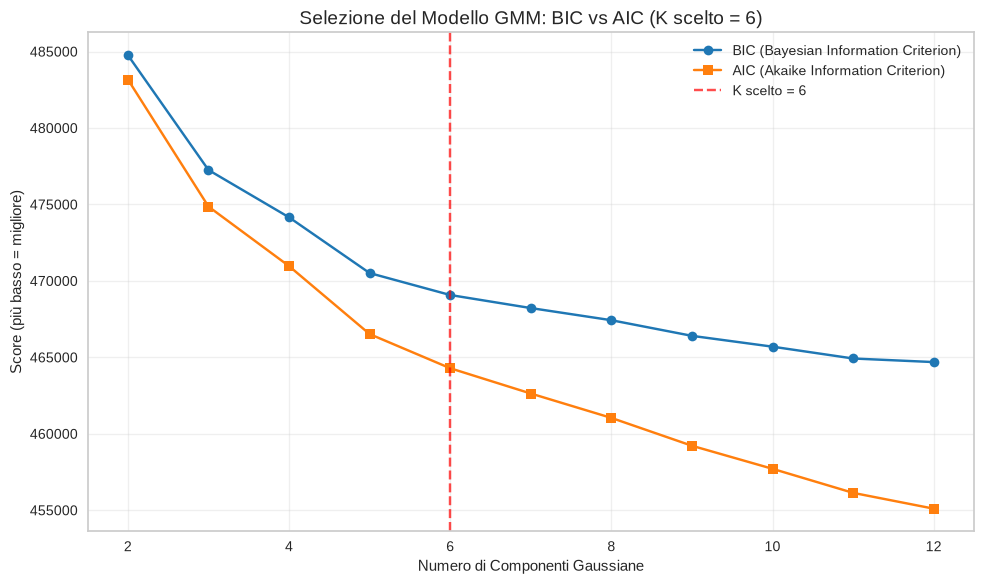


Numero ottimale di componenti secondo BIC: 12 (Configurato a K=6 per coerenza)
  -> Per mantenere il confronto omogeneo useremo K=6 come stabilito.


In [18]:
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt
import numpy as np

print("--- FASE 3d: SELEZIONE DEL MODELLO GMM (BIC / AIC) ---")

# Testiamo diversi numeri di componenti (equivalente a K nel K-Means)
n_components_range = range(2, 13)
bic_scores = []
aic_scores = []

print("Calcolo BIC e AIC al variare del numero di componenti...")
for n in n_components_range:
    gmm_test = GaussianMixture(
        n_components=n,
        covariance_type='full',  # Gaussiane con matrice di covarianza completa (ellissoidali)
        n_init=5,                # Numero di inizializzazioni per robustezza
        random_state=42,
        max_iter=300
    )
    gmm_test.fit(X_search)  # Usiamo il campione per velocizzare
    bic_scores.append(gmm_test.bic(X_search))
    aic_scores.append(gmm_test.aic(X_search))

# Plot BIC e AIC
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
ax.plot(list(n_components_range), bic_scores, marker='o', color='#1f77b4', label='BIC (Bayesian Information Criterion)')
ax.plot(list(n_components_range), aic_scores, marker='s', color='#ff7f0e', label='AIC (Akaike Information Criterion)')
ax.axvline(x=6, color='red', linestyle='--', alpha=0.7, label='K scelto = 6')
ax.set_xlabel('Numero di Componenti Gaussiane')
ax.set_ylabel('Score (più basso = migliore)')
ax.set_title('Selezione del Modello GMM: BIC vs AIC (K scelto = 6)', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

best_n_bic = list(n_components_range)[np.argmin(bic_scores)]
best_n_aic = list(n_components_range)[np.argmin(aic_scores)]
print(f"\nNumero ottimale di componenti secondo BIC: {best_n_bic} (Configurato a K=6 per coerenza)")
print(f"  -> Per mantenere il confronto omogeneo useremo K=6 come stabilito.")

--- ADDESTRAMENTO GMM E MAPPATURA SPAZIALE ---


Convergenza raggiunta: True
Log-likelihood finale: -15.4473
BIC: 2781078.65
AIC: 2775162.79

Distribuzione dei cluster GMM (allineati):
cluster_gmm
0    26075
1    11284
2     6846
3    13365
4    14283
5    17933

Pixel con assegnazione incerta (prob < 70%): 13773 (15.3%)
Probabilità media del cluster assegnato: 0.885


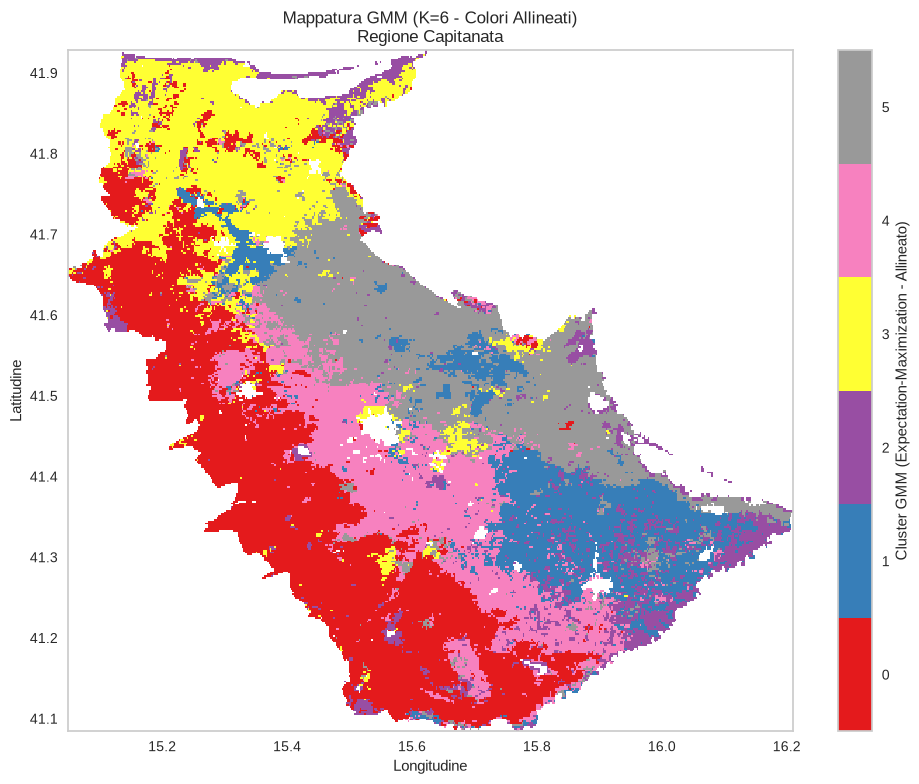

In [19]:
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

print("--- ADDESTRAMENTO GMM E MAPPATURA SPAZIALE ---")

K_GMM = 6
gmm_model = GaussianMixture(
    n_components=K_GMM,
    covariance_type='full',
    n_init=10,
    random_state=42,
    max_iter=300
)

# Fit e predizione
gmm_model.fit(X_scaled)
gmm_labels = gmm_model.predict(X_scaled)
df_ml['cluster_gmm'] = align_clusters(df_ml['cluster'], gmm_labels)

# Calcolo probabilità (soft assignment) per diagnostica incertezza
gmm_probs = gmm_model.predict_proba(X_scaled)
max_probs = gmm_probs.max(axis=1)
uncertain_pixels = np.sum(max_probs < 0.7)

print(f"Convergenza raggiunta: {gmm_model.converged_}")
print(f"Log-likelihood finale: {gmm_model.score(X_scaled):.4f}")
print(f"BIC: {gmm_model.bic(X_scaled):.2f}")
print(f"AIC: {gmm_model.aic(X_scaled):.2f}")

print('\nDistribuzione dei cluster GMM (allineati):')
print(df_ml['cluster_gmm'].value_counts().sort_index().to_string())

print(f'\nPixel con assegnazione incerta (prob < 70%): {uncertain_pixels} ({uncertain_pixels/len(max_probs)*100:.1f}%)')
print(f'Probabilità media del cluster assegnato: {max_probs.mean():.3f}')

# Costruzione griglia e visualizzazione spaziale
da_gmm = df_ml.set_index(['lat', 'lon'])['cluster_gmm'].to_xarray()

plt.figure(figsize=(10, 8))
ax = plt.axes()
da_gmm.plot(ax=ax, cmap=soil_cmap, add_colorbar=False)

cbar = plt.colorbar(
    plt.cm.ScalarMappable(
        cmap=soil_cmap,
        norm=mcolors.Normalize(vmin=-0.5, vmax=K_GMM - 0.5)
    ),
    ticks=range(K_GMM),
    ax=ax
)
cbar.set_label('Cluster GMM (Expectation-Maximization - Allineato)')

plt.title(f"Mappatura GMM (K={K_GMM} - Colori Allineati)\nRegione Capitanata")
plt.xlabel("Longitudine")
plt.ylabel("Latitudine")
plt.tight_layout()
plt.show()

#**FASE 6: Cluster Validation**
### Concludiamo l'analisi misurando le performance dei modelli allenati. Trattandosi di algoritmi senza etichette predefinite, ci affidiamo ad indici interni: la Sum of Squared Error (SSE), per minimizzare la varianza interna, e il Coefficiente di Silhouette, per valutare la corretta separazione spaziale.

In [20]:
import pandas as pd
import numpy as np
from sklearn.metrics import silhouette_score

print("--- FASE 6: CLUSTER VALIDATION (Confronto Modelli) ---")

if 'idx' in locals():
    sample_labels_kmeans = final_labels[idx]
    sample_labels_dbscan = dbscan_labels[idx]
    sample_labels_bisecting = df_ml['cluster_bisecting'].values[idx]
    sample_labels_gmm = gmm_labels[idx]
    X_val = X_search  # X_search è già il campione indicizzato da idx
else:
    sample_labels_kmeans = final_labels
    sample_labels_dbscan = dbscan_labels
    sample_labels_bisecting = df_ml['cluster_bisecting'].values
    sample_labels_gmm = gmm_labels
    X_val = X_scaled

print("Calcolo dei Coefficienti di Silhouette in corso...")

# Calcolo Silhouette Score
try:
    sil_kmeans = silhouette_score(X_val, sample_labels_kmeans)
except ValueError:
    sil_kmeans = "N/A"

mask_no_noise = sample_labels_dbscan != -1
n_noise_sample = np.sum(~mask_no_noise)
n_clusters_dbscan = len(np.unique(sample_labels_dbscan[mask_no_noise]))
try:
    if mask_no_noise.sum() > 0 and n_clusters_dbscan >= 2:
        sil_dbscan = silhouette_score(X_val[mask_no_noise], sample_labels_dbscan[mask_no_noise])
    else:
        sil_dbscan = "N/A (cluster insufficienti)"
except ValueError:
    sil_dbscan = "N/A"

print(f"  -> DBSCAN: {n_noise_sample} punti di rumore esclusi dal calcolo Silhouette")

# Bisecting K-Means
try:
    sil_bisecting = silhouette_score(X_val, sample_labels_bisecting)
except ValueError:
    sil_bisecting = "N/A"

# GMM (EM)
try:
    sil_gmm = silhouette_score(X_val, sample_labels_gmm)
except ValueError:
    sil_gmm = "N/A"

# Recupero della Sum of Squared Error (SSE / Inertia)
sse_kmeans = final_model.inertia_
sse_bisecting = bisect_kmeans.inertia_
sse_dbscan = "N/A (Density-based)"
sse_gmm = "N/A (Likelihood-based)"

# Creazione tabella riassuntiva (Uniformata con K=6)
validation_results = pd.DataFrame({
    'Algoritmo': [
        'K-Means (K=6)',
        'Bisecting K-Means (K=6)',
        f'DBSCAN (eps={EPS_SCELTO})',
        f'GMM / EM (K={K_GMM})'
    ],
    'Silhouette Score (↑ Migliore)': [sil_kmeans, sil_bisecting, sil_dbscan, sil_gmm],
    'SSE / Inertia (↓ Migliore)': [sse_kmeans, sse_bisecting, sse_dbscan, sse_gmm]
})

print("\nTabella di Validazione Interna e Relativa dei Cluster:")
print("-" * 80)
print(validation_results.to_string(index=False))
print("-" * 80)

from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

ari_km_bisect = adjusted_rand_score(df_ml['cluster'], df_ml['cluster_bisecting'])
ari_km_gmm = adjusted_rand_score(df_ml['cluster'], df_ml['cluster_gmm'])
nmi_km_gmm = normalized_mutual_info_score(df_ml['cluster'], df_ml['cluster_gmm'])
nmi_km_bisect= normalized_mutual_info_score(df_ml['cluster'], df_ml['cluster_bisecting'])

print(f"ARI (K-Means vs Bisecting): {ari_km_bisect:.3f}")
print(f"ARI (K-Means vs GMM): {ari_km_gmm:.3f}")
print(f"NMI (K-Means vs GMM): {nmi_km_gmm:.3f}")
print(f"NMI (K-Means vs Bisecting): {nmi_km_bisect:.3f}")

--- FASE 6: CLUSTER VALIDATION (Confronto Modelli) ---
Calcolo dei Coefficienti di Silhouette in corso...


  -> DBSCAN: 934 punti di rumore esclusi dal calcolo Silhouette



Tabella di Validazione Interna e Relativa dei Cluster:
--------------------------------------------------------------------------------
              Algoritmo  Silhouette Score (↑ Migliore) SSE / Inertia (↓ Migliore)
          K-Means (K=6)                       0.104097              762167.365695
Bisecting K-Means (K=6)                       0.073917              793840.537575
       DBSCAN (eps=1.9)                       0.086850        N/A (Density-based)
         GMM / EM (K=6)                       0.065782     N/A (Likelihood-based)
--------------------------------------------------------------------------------
ARI (K-Means vs Bisecting): 0.458
ARI (K-Means vs GMM): 0.387
NMI (K-Means vs GMM): 0.462
NMI (K-Means vs Bisecting): 0.546


#**FASE 6b: Efficienza sui Grandi Dati (Mini-Batch K-Means)**
### Avendo un dataset spaziale molto grande (~94.000 pixel), l'addestramento del K-Means standard richiede molte risorse geometriche. Testiamo l'algoritmo `MiniBatchKMeans`, che elabora i dati a piccoli blocchi, per valutare il trade-off tra velocità di addestramento (tempo in secondi) e precisione del clustering (Inerzia/SSE).

In [21]:
import time
from sklearn.cluster import KMeans, MiniBatchKMeans
import pandas as pd

print("--- FASE 6b: CONFRONTO EFFICIENZA K-MEANS vs MINI-BATCH K-MEANS ---")

# Utilizziamo il K=6 scelto coerentemente
k_final = 6

# 1. Test K-Means Standard sull'intero dataset
print("Addestramento K-Means standard in corso...")
start_time = time.time()
kmeans_full = KMeans(n_clusters=k_final, init='k-means++', n_init=10, max_iter=300, random_state=42)
kmeans_full.fit(X_scaled)
time_kmeans = time.time() - start_time
inertia_kmeans = kmeans_full.inertia_

# 2. Test Mini-Batch K-Means sull'intero dataset
print("Addestramento Mini-Batch K-Means in corso...")
start_time = time.time()
# Usiamo un batch_size tipico (es. 1024 o 2048 pixel alla volta)
minibatch_kmeans = MiniBatchKMeans(n_clusters=k_final, random_state=42, batch_size=1024)
minibatch_kmeans.fit(X_scaled)
time_minibatch = time.time() - start_time
inertia_minibatch = minibatch_kmeans.inertia_

# 3. Creazione Tabella Comparativa
comparison_df = pd.DataFrame({
    'Algoritmo (Intero Dataset)': ['K-Means Standard', 'Mini-Batch K-Means'],
    'Tempo di Addestramento (sec) ↓': [f"{time_kmeans:.3f}", f"{time_minibatch:.3f}"],
    'Inerzia (SSE) ↓': [f"{inertia_kmeans:.2f}", f"{inertia_minibatch:.2f}"]
})

print("\nRisultati del Confronto su ~94k pixel:")
print("-" * 75)
print(comparison_df.to_string(index=False))
print("-" * 75)
print("\nNota: Il Mini-Batch K-Means è tipicamente più veloce ma con un'Inerzia leggermente superiore.")

--- FASE 6b: CONFRONTO EFFICIENZA K-MEANS vs MINI-BATCH K-MEANS ---
Addestramento K-Means standard in corso...


Addestramento Mini-Batch K-Means in corso...

Risultati del Confronto su ~94k pixel:
---------------------------------------------------------------------------
Algoritmo (Intero Dataset) Tempo di Addestramento (sec) ↓ Inerzia (SSE) ↓
          K-Means Standard                          0.532       762168.13
        Mini-Batch K-Means                          0.159       780138.45
---------------------------------------------------------------------------

Nota: Il Mini-Batch K-Means è tipicamente più veloce ma con un'Inerzia leggermente superiore.
